# Diseño de filtros digitales FIR
**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from zplane_graph import zplane

## Señal de prueba: ECG

Trabajamos con una señal de ECG con frecuencia de muestreo $f_s = 200$ Hz, que contiene ruido de red eléctrica (60 Hz) y ruido de alta frecuencia.

In [2]:
ecg = np.loadtxt("./ECG.txt")

fs = 200
N = len(ecg)
n = np.arange(N)
t = n / fs

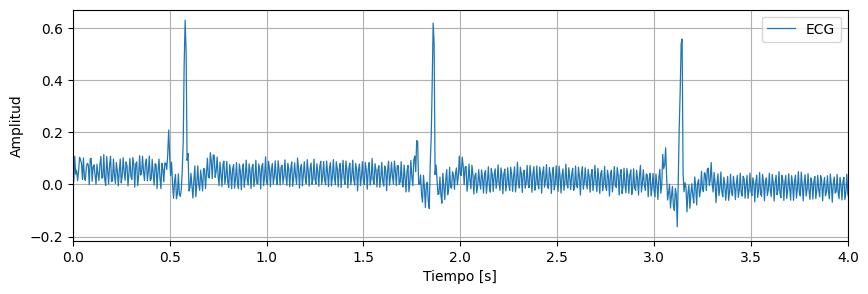

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t, ecg, linewidth=0.9, label="ECG")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend()
ax.grid(True)

Veamos el espectro de la señal para identificar los componentes de frecuencia:

In [4]:
def plot_spectrum(signal, fs, N, f_marks=None, label="Señal", color=None):
    sig_fft = np.fft.fft(signal)
    f = (fs / N) * np.arange(N)

    kwargs = {"label": label, "linewidth": 0.9}
    if color:
        kwargs["color"] = color

    plt.plot(f[:N // 2], np.abs(sig_fft)[:N // 2], **kwargs)

    if f_marks:
        for fm in f_marks:
            plt.axvline(x=fm, color="red", linewidth=1, linestyle="--")

    plt.xlabel("f [Hz]")
    plt.ylabel("|FFT|")
    plt.xlim([0, fs / 2])
    plt.grid(True)

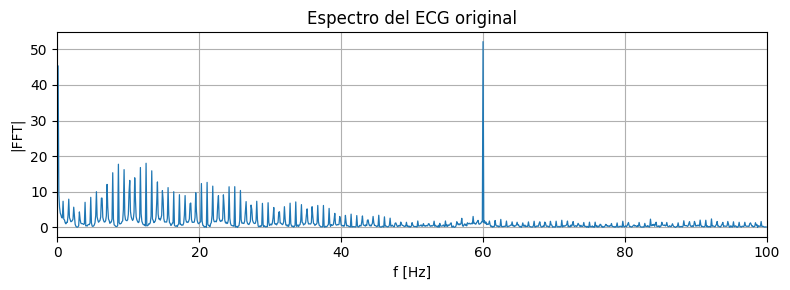

In [5]:
plt.figure(figsize=(8, 3))
plot_spectrum(ecg, fs, N)
plt.title("Espectro del ECG original")
plt.tight_layout()

Identificamos dos componentes de ruido:
- **Alta frecuencia (> 40 Hz):** ruido que distorsiona la morfología del ECG
- **~60 Hz:** interferencia de la red eléctrica

Diseñaremos dos filtros FIR:
1. **Filtro pasa-bajos** con frecuencia de corte en 40 Hz
2. **Filtro bloquea-banda** para eliminar la interferencia de 60 Hz (banda 55–65 Hz)

---
## Funciones auxiliares

In [6]:
def obtain_response(b, fs, N):
    w, H = sp.signal.freqz(b, [1], fs=fs, worN=N)
    return w, H

def plot_response(w, H, fs, ylim_limits=(-80, 10), title="Respuesta en frecuencia"):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(w, 20 * np.log10(np.abs(H) + 1e-12))
    ax[1].plot(w, np.angle(H, deg=True))
    ax[0].grid(True)
    ax[1].grid(True)
    ax[0].set_ylabel("|H(ω)| [dB]")
    ax[1].set_ylabel("Fase [deg]")
    ax[0].set_xlabel("f [Hz]")
    ax[1].set_xlabel("f [Hz]")
    ax[0].set_ylim(ylim_limits)
    ax[0].set_xlim([0, fs / 2])
    ax[1].set_xlim([0, fs / 2])
    fig.suptitle(title)
    plt.tight_layout()

def plot_impulse_response(b, title="Respuesta al impulso h[n]"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.stem(b)
    ax.set_title(title)
    ax.set_xlabel("n (muestras)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)
    plt.tight_layout()

def compare_signals(t, original, filtered, xlim=(0, 4), label_filt="Filtrado"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
    ax.plot(t, original, linewidth=0.8, label="Original", alpha=0.5)
    ax.plot(t, filtered, linewidth=1, color="red", label=label_filt)
    ax.set_xlim(xlim)
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Amplitud")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

In [7]:
def diseno_fir(wc, tipo, M, ventana="hamming"):
    """
    Diseña un filtro FIR por el método de la ventana.

    Parámetros
    ----------
    wc     : frecuencia(s) de corte normalizada(s) en radianes.
             Escalar para LP/HP; tupla (wc1, wc2) para BP/BS.
    tipo   : 'lp', 'hp', 'bp', 'bs'
    M      : número de coeficientes
    ventana: 'rectangular', 'hamming' o 'blackman'

    Retorna
    -------
    b : array con los M+1 coeficientes del filtro FIR
    """
    k = np.arange(-M // 2, M // 2 + 1)
    k_safe = np.where(k == 0, 1, k)

    if tipo == "lp":
        b_ideal = np.where(k == 0, wc / np.pi, np.sin(k_safe * wc) / (k_safe * np.pi))
    elif tipo == "hp":
        b_ideal = np.where(k == 0, 1 - wc / np.pi, -np.sin(k_safe * wc) / (k_safe * np.pi))
    elif tipo == "bp":
        wc1, wc2 = wc
        b_ideal = np.where(
            k == 0,
            (wc2 - wc1) / np.pi,
            (np.sin(k_safe * wc2) - np.sin(k_safe * wc1)) / (k_safe * np.pi)
        )
    elif tipo == "bs":
        wc1, wc2 = wc
        b_ideal = np.where(
            k == 0,
            1 - (wc2 - wc1) / np.pi,
            (np.sin(k_safe * wc1) - np.sin(k_safe * wc2)) / (k_safe * np.pi)
        )
    else:
        raise ValueError(f"Tipo '{tipo}' no reconocido.")

    L = len(k)
    if ventana == "rectangular":
        w = np.ones(L)
    elif ventana == "hamming":
        w = np.hamming(L)
    elif ventana == "blackman":
        w = np.blackman(L)
    else:
        raise ValueError(f"Ventana '{ventana}' no reconocida.")

    return b_ideal * w

---
## 1. Filtro pasa-bajos FIR

### 1.1 Especificaciones

- **Tipo:** pasa-bajos
- **Frecuencia de corte:** $f_c = 40$ Hz
- **Frecuencia normalizada:** $\omega_c = 2\pi f_c / f_s$

### 1.2 Coeficientes ideales

Para un filtro pasa-bajos ideal:

$$b[k] = \begin{cases} \dfrac{\omega_c}{\pi} & k = 0 \\[8pt] \dfrac{\text{sen}(k\,\omega_c)}{k\,\pi} & k \neq 0 \end{cases}$$

In [8]:
fc = 40
wc = 2 * np.pi * fc / fs

print(f"Frecuencia de corte: fc = {fc} Hz")
print(f"Frecuencia de corte normalizada: wc = {wc:.4f} rad")
print(f"wc / pi = {wc / np.pi:.4f}")

Frecuencia de corte: fc = 40 Hz
Frecuencia de corte normalizada: wc = 1.2566 rad
wc / pi = 0.4000


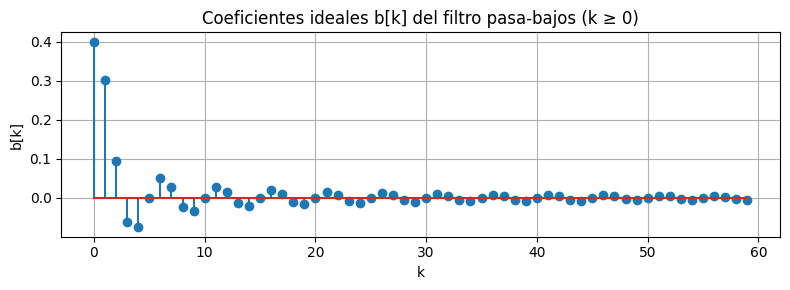

In [9]:
k_vals = np.arange(0, 60)
k_safe = np.where(k_vals == 0, 1, k_vals)
b_ideal_lp = np.where(k_vals == 0, wc / np.pi, np.sin(k_safe * wc) / (k_safe * np.pi))

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.stem(k_vals, b_ideal_lp)
ax.set_title("Coeficientes ideales b[k] del filtro pasa-bajos (k ≥ 0)")
ax.set_xlabel("k")
ax.set_ylabel("b[k]")
ax.grid(True)
plt.tight_layout()

Los coeficientes son infinitos (sinc). Debemos **truncar** con una ventana.

### 1.3 Efecto del número de coeficientes $M$

Probamos con $M = 10$, $20$ y $60$ usando ventana rectangular.

Los filtros FIR solo tienen **ceros** (todos los polos en el origen). Al aumentar $M$, los ceros se acumulan sobre el círculo unitario en la zona de bloqueo.

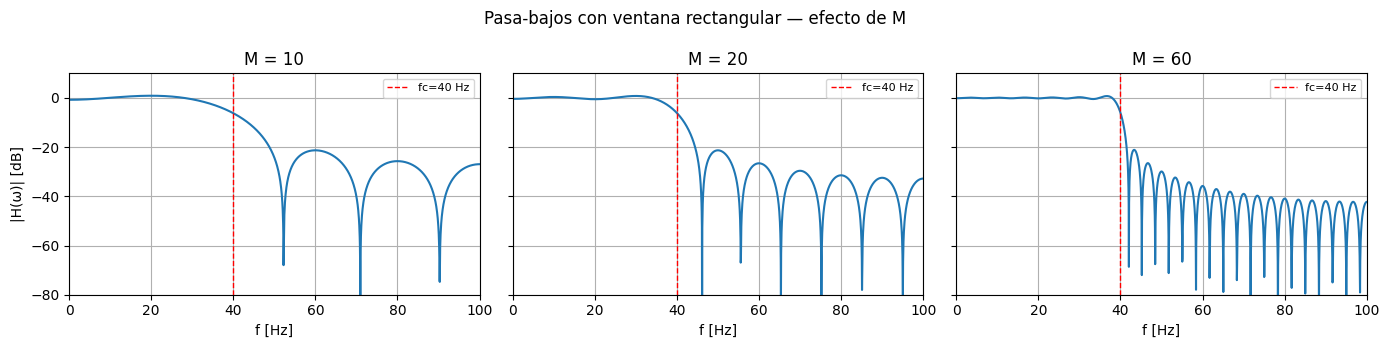

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for ax, M in zip(axes, [10, 20, 60]):
    b_tmp = diseno_fir(wc, "lp", M, ventana="rectangular")
    w_resp, H = obtain_response(b_tmp, fs, N)
    ax.plot(w_resp, 20 * np.log10(np.abs(H) + 1e-12))
    ax.axvline(x=fc, color="red", linestyle="--", linewidth=1, label=f"fc={fc} Hz")
    ax.set_title(f"M = {M}")
    ax.set_xlabel("f [Hz]")
    ax.set_xlim([0, fs / 2])
    ax.set_ylim([-80, 10])
    ax.grid(True)
    ax.legend(fontsize=8)

axes[0].set_ylabel("|H(ω)| [dB]")
fig.suptitle("Pasa-bajos con ventana rectangular — efecto de M")
plt.tight_layout()

Diagrama de polos y ceros para cada $M$:

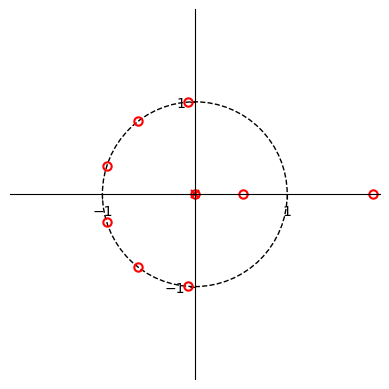

In [11]:
b_tmp = diseno_fir(wc, "lp", 10, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

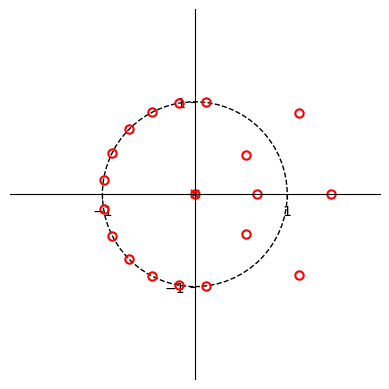

In [12]:
b_tmp = diseno_fir(wc, "lp", 20, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

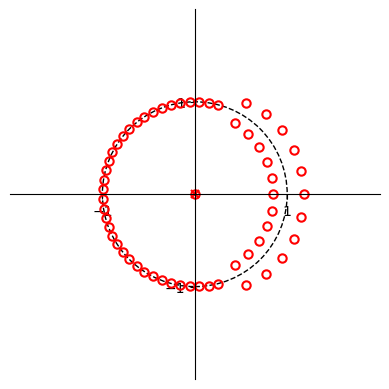

In [13]:
b_tmp = diseno_fir(wc, "lp", 60, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

A mayor $M$, más ceros se acumulan sobre el círculo unitario en la banda de bloqueo, mejorando la selectividad.

### 1.4 Efecto de la ventana

Comparamos ventana rectangular, Hamming y Blackman con $M = 40$:

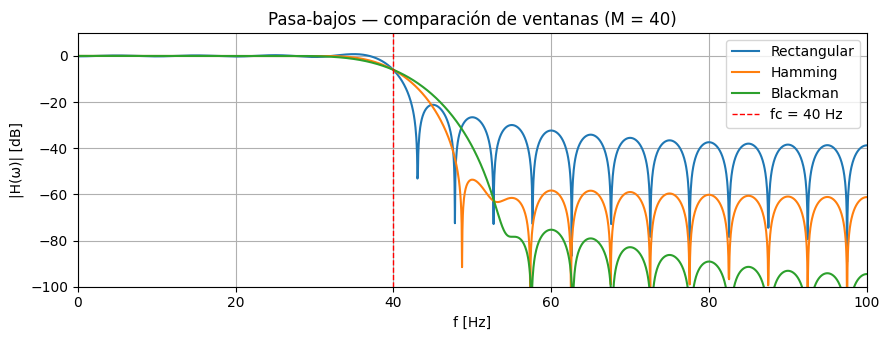

In [14]:
M_lp = 40
ventanas = ["rectangular", "hamming", "blackman"]
colores  = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(1, 1, figsize=(9, 3.5))

for vent, color in zip(ventanas, colores):
    b_tmp = diseno_fir(wc, "lp", M_lp, ventana=vent)
    w_resp, H = obtain_response(b_tmp, fs, N)
    ax.plot(w_resp, 20 * np.log10(np.abs(H) + 1e-12), label=vent.capitalize(), color=color)

ax.axvline(x=fc, color="red", linestyle="--", linewidth=1, label=f"fc = {fc} Hz")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|H(ω)| [dB]")
ax.set_xlim([0, fs / 2])
ax.set_ylim([-100, 10])
ax.set_title(f"Pasa-bajos — comparación de ventanas (M = {M_lp})")
ax.legend()
ax.grid(True)
plt.tight_layout()

Diagrama de polos y ceros para cada ventana:

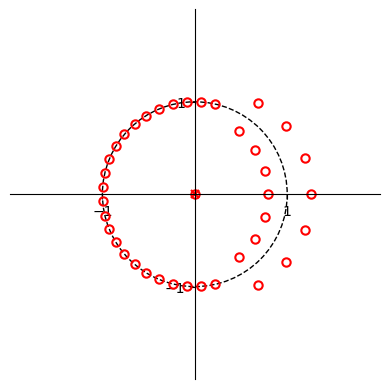

In [15]:
b_tmp = diseno_fir(wc, "lp", M_lp, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

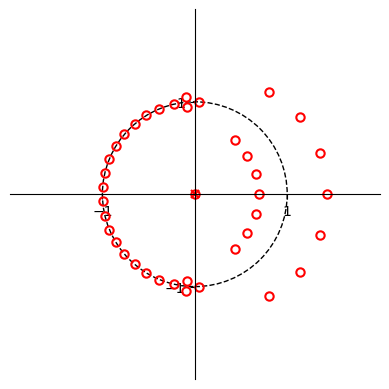

In [16]:
b_tmp = diseno_fir(wc, "lp", M_lp, ventana="hamming")
zplane(b_tmp, np.array([1.0]));

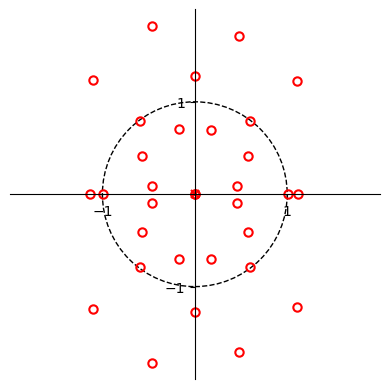

In [17]:
b_tmp = diseno_fir(wc, "lp", M_lp, ventana="blackman")
zplane(b_tmp, np.array([1.0]));

- **Rectangular:** ceros bien concentrados sobre el círculo unitario, rizado visible (Gibbs).
- **Hamming / Blackman:** ceros más dispersos, menor rizado pero zona de transición más ancha.

Elegimos **Hamming con $M = 40$**.

### 1.5 Filtro final pasa-bajos

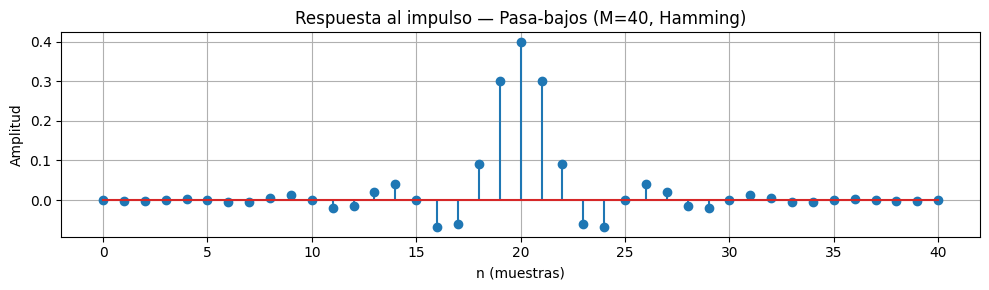

In [18]:
b_lp = diseno_fir(wc, "lp", M_lp, ventana="hamming")

plot_impulse_response(b_lp, title=f"Respuesta al impulso — Pasa-bajos (M={M_lp}, Hamming)")

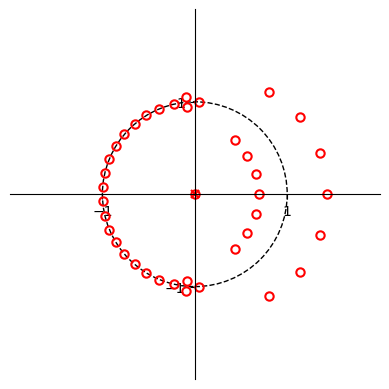

In [19]:
zplane(b_lp, np.array([1.0]));

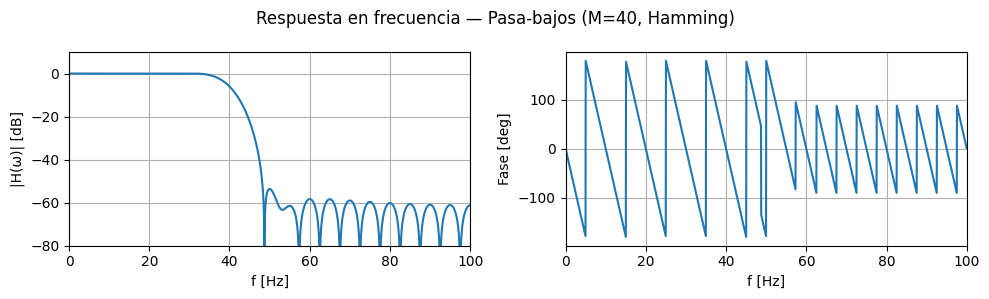

In [20]:
w_lp, H_lp = obtain_response(b_lp, fs, N)
plot_response(w_lp, H_lp, fs, title=f"Respuesta en frecuencia — Pasa-bajos (M={M_lp}, Hamming)")

La **fase es lineal** en la banda de paso, característica fundamental de los filtros FIR.

### 1.6 Aplicación del filtro

Usamos `np.convolve(mode='same')` para que el retardo de $M/2$ muestras quede compensado:

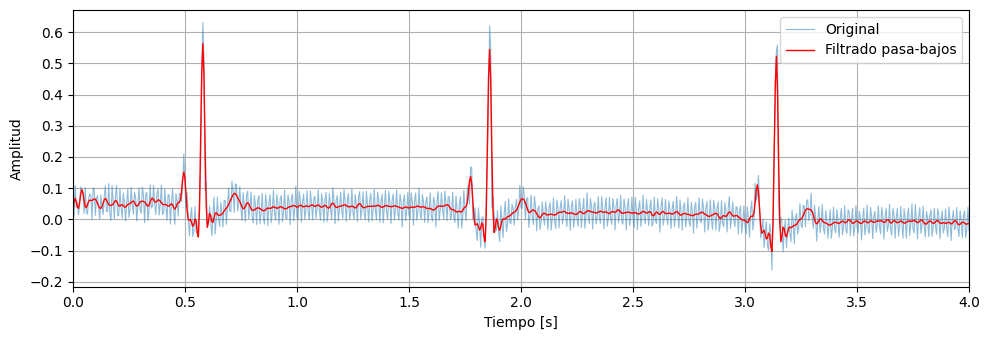

In [21]:
ecg_lp = np.convolve(ecg, b_lp, mode="same")

compare_signals(t, ecg, ecg_lp, label_filt="Filtrado pasa-bajos")

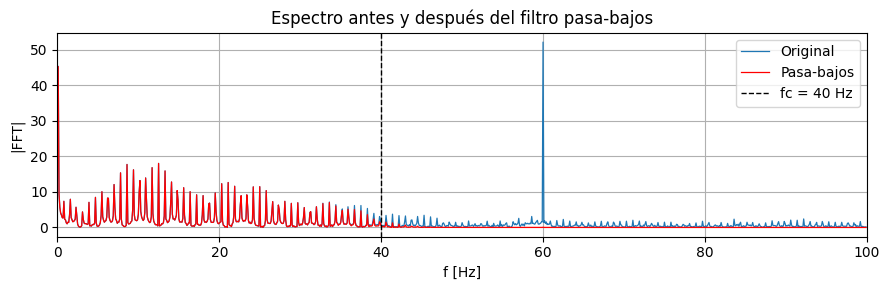

In [22]:
plt.figure(figsize=(9, 3))
plot_spectrum(ecg, fs, N, label="Original")
plot_spectrum(ecg_lp, fs, N, label="Pasa-bajos", color="red")
plt.axvline(x=fc, color="black", linestyle="--", linewidth=1, label=f"fc = {fc} Hz")
plt.title("Espectro antes y después del filtro pasa-bajos")
plt.legend()
plt.tight_layout()

---
## 2. Filtro bloquea-banda FIR

### 2.1 Especificaciones

- **Tipo:** bloquea-banda
- **Frecuencias de corte:** $f_{c1} = 55$ Hz y $f_{c2} = 65$ Hz

### 2.2 Coeficientes ideales

$$b[k] = \begin{cases} 1 - \dfrac{\omega_{c2}-\omega_{c1}}{\pi} & k = 0 \\[8pt] \dfrac{\text{sen}(k\,\omega_{c1}) - \text{sen}(k\,\omega_{c2})}{k\,\pi} & k \neq 0 \end{cases}$$

In [23]:
fc1 = 55
fc2 = 65

wc1 = 2 * np.pi * fc1 / fs
wc2 = 2 * np.pi * fc2 / fs

print(f"Banda de bloqueo: {fc1}–{fc2} Hz")
print(f"wc1 = {wc1:.4f} rad  |  wc2 = {wc2:.4f} rad")

Banda de bloqueo: 55–65 Hz
wc1 = 1.7279 rad  |  wc2 = 2.0420 rad


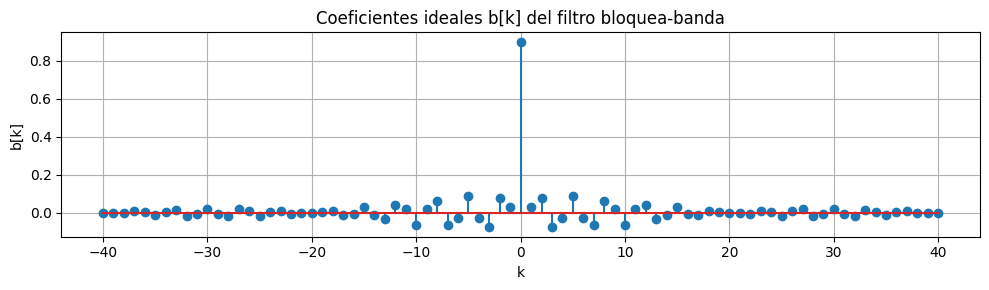

In [24]:
M_show = 80
k_vals = np.arange(-M_show // 2, M_show // 2 + 1)
k_safe = np.where(k_vals == 0, 1, k_vals)

b_ideal_bs = np.where(
    k_vals == 0,
    1 - (wc2 - wc1) / np.pi,
    (np.sin(k_safe * wc1) - np.sin(k_safe * wc2)) / (k_safe * np.pi)
)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.stem(k_vals, b_ideal_bs)
ax.set_title("Coeficientes ideales b[k] del filtro bloquea-banda")
ax.set_xlabel("k")
ax.set_ylabel("b[k]")
ax.grid(True)
plt.tight_layout()

### 2.3 Efecto del número de coeficientes $M$

Para una banda angosta (10 Hz) se necesitan más coeficientes. Probamos con $M = 20$, $60$ y $100$:

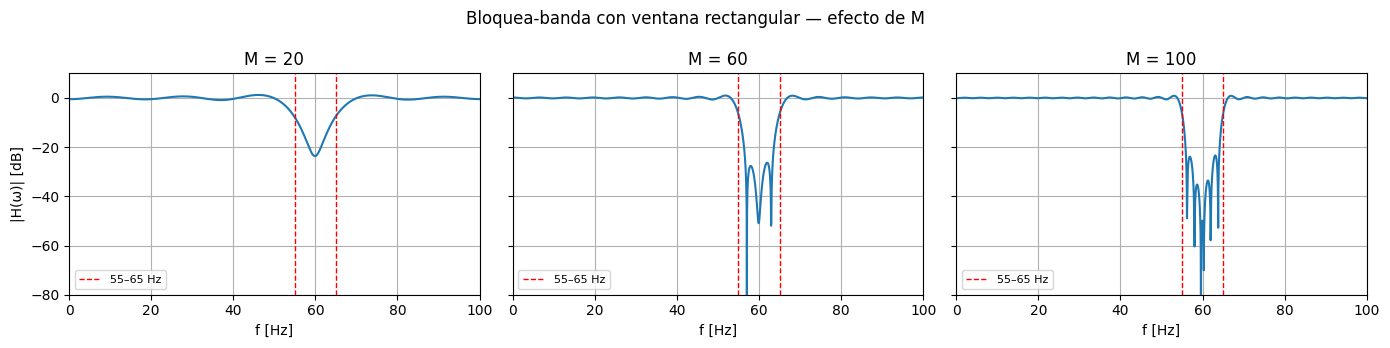

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for ax, M in zip(axes, [20, 60, 100]):
    b_tmp = diseno_fir((wc1, wc2), "bs", M, ventana="rectangular")
    w_resp, H = obtain_response(b_tmp, fs, N)
    ax.plot(w_resp, 20 * np.log10(np.abs(H) + 1e-12))
    ax.axvline(x=fc1, color="red", linestyle="--", linewidth=1)
    ax.axvline(x=fc2, color="red", linestyle="--", linewidth=1, label=f"{fc1}–{fc2} Hz")
    ax.set_title(f"M = {M}")
    ax.set_xlabel("f [Hz]")
    ax.set_xlim([0, fs / 2])
    ax.set_ylim([-80, 10])
    ax.grid(True)
    ax.legend(fontsize=8)

axes[0].set_ylabel("|H(ω)| [dB]")
fig.suptitle("Bloquea-banda con ventana rectangular — efecto de M")
plt.tight_layout()

Diagrama de polos y ceros para cada $M$:

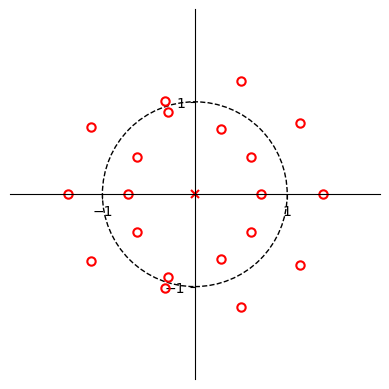

In [26]:
b_tmp = diseno_fir((wc1, wc2), "bs", 20, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

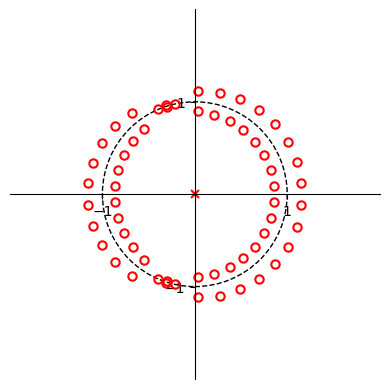

In [27]:
b_tmp = diseno_fir((wc1, wc2), "bs", 60, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

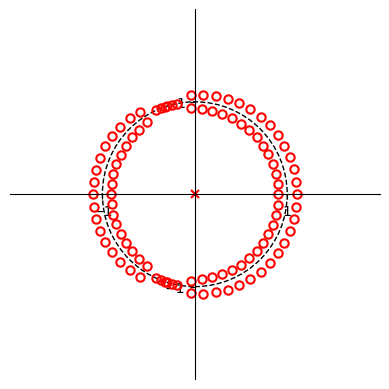

In [28]:
b_tmp = diseno_fir((wc1, wc2), "bs", 100, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

Los ceros se concentran sobre el círculo unitario en la zona 55–65 Hz. Con más coeficientes la atenuación es mayor y más selectiva.

### 2.4 Efecto de la ventana

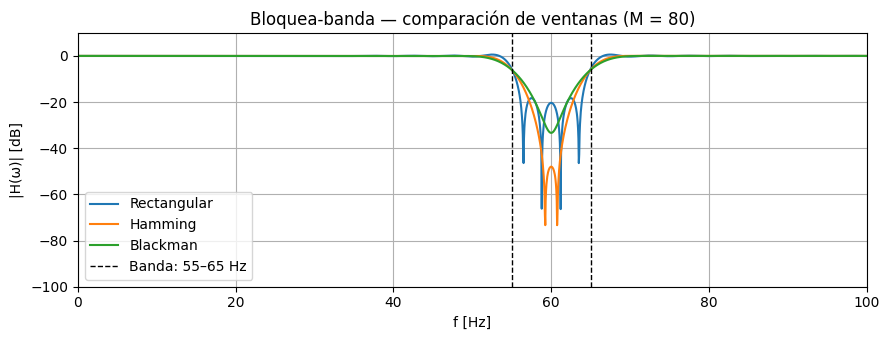

In [29]:
M_bs = 80
ventanas = ["rectangular", "hamming", "blackman"]
colores  = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(1, 1, figsize=(9, 3.5))

for vent, color in zip(ventanas, colores):
    b_tmp = diseno_fir((wc1, wc2), "bs", M_bs, ventana=vent)
    w_resp, H = obtain_response(b_tmp, fs, N)
    ax.plot(w_resp, 20 * np.log10(np.abs(H) + 1e-12), label=vent.capitalize(), color=color)

ax.axvline(x=fc1, color="black", linestyle="--", linewidth=1)
ax.axvline(x=fc2, color="black", linestyle="--", linewidth=1, label=f"Banda: {fc1}–{fc2} Hz")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|H(ω)| [dB]")
ax.set_xlim([0, fs / 2])
ax.set_ylim([-100, 10])
ax.set_title(f"Bloquea-banda — comparación de ventanas (M = {M_bs})")
ax.legend()
ax.grid(True)
plt.tight_layout()

Diagrama de polos y ceros para cada ventana:

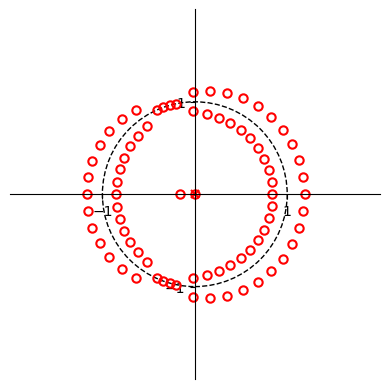

In [30]:
b_tmp = diseno_fir((wc1, wc2), "bs", M_bs, ventana="rectangular")
zplane(b_tmp, np.array([1.0]));

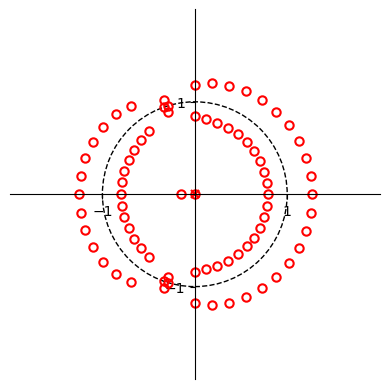

In [31]:
b_tmp = diseno_fir((wc1, wc2), "bs", M_bs, ventana="hamming")
zplane(b_tmp, np.array([1.0]));

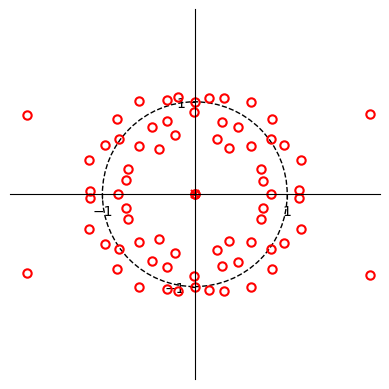

In [32]:
b_tmp = diseno_fir((wc1, wc2), "bs", M_bs, ventana="blackman")
zplane(b_tmp, np.array([1.0]));

Elegimos **Hamming con $M = 80$**.

### 2.5 Filtro final bloquea-banda

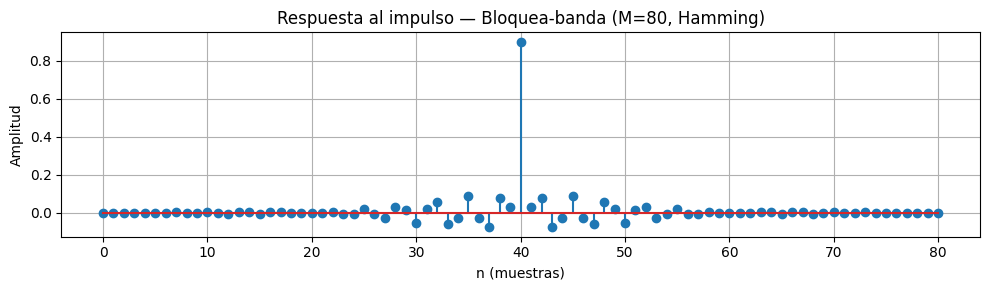

In [33]:
b_bs = diseno_fir((wc1, wc2), "bs", M_bs, ventana="hamming")

plot_impulse_response(b_bs, title=f"Respuesta al impulso — Bloquea-banda (M={M_bs}, Hamming)")

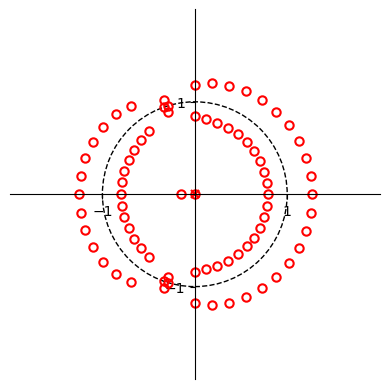

In [34]:
zplane(b_bs, np.array([1.0]));

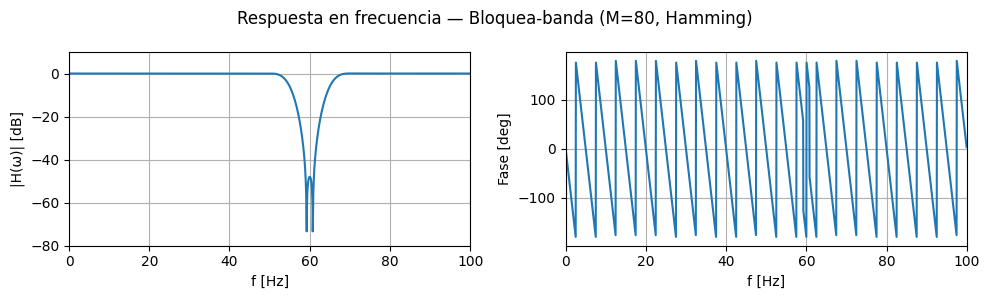

In [35]:
w_bs, H_bs = obtain_response(b_bs, fs, N)
plot_response(w_bs, H_bs, fs, title=f"Respuesta en frecuencia — Bloquea-banda (M={M_bs}, Hamming)")

### 2.6 Aplicación del filtro

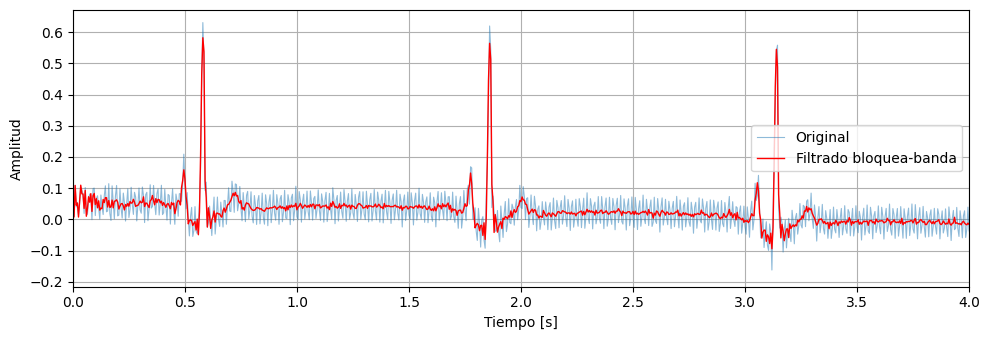

In [36]:
ecg_bs = np.convolve(ecg, b_bs, mode="same")

compare_signals(t, ecg, ecg_bs, label_filt="Filtrado bloquea-banda")

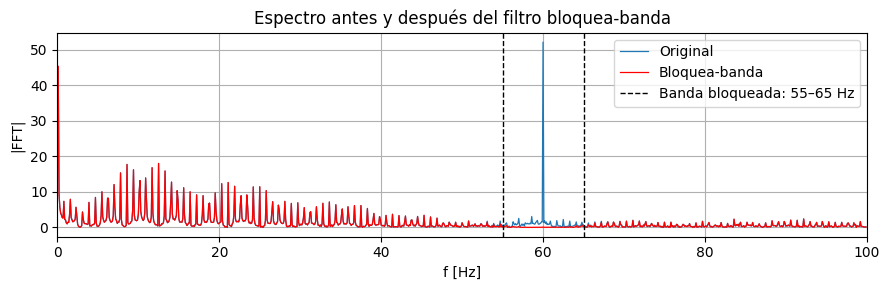

In [37]:
plt.figure(figsize=(9, 3))
plot_spectrum(ecg, fs, N, label="Original")
plot_spectrum(ecg_bs, fs, N, label="Bloquea-banda", color="red")
plt.axvline(x=fc1, color="black", linestyle="--", linewidth=1)
plt.axvline(x=fc2, color="black", linestyle="--", linewidth=1, label=f"Banda bloqueada: {fc1}–{fc2} Hz")
plt.title("Espectro antes y después del filtro bloquea-banda")
plt.legend()
plt.tight_layout()

---
## 3. Comparación final: aplicación en cadena

Aplicamos los dos filtros en **cascada**: primero el bloquea-banda (elimina 60 Hz) y luego el pasa-bajos (elimina el resto del ruido de alta frecuencia).

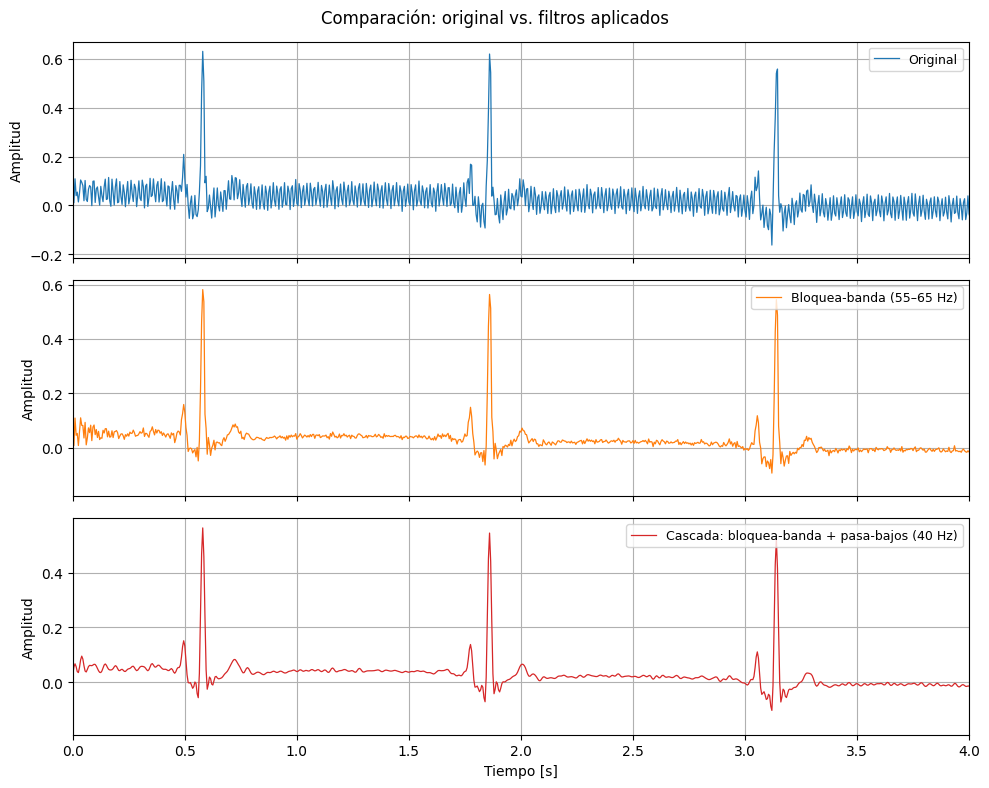

In [38]:
ecg_bs_lp = np.convolve(
    np.convolve(ecg, b_bs, mode="same"),
    b_lp,
    mode="same"
)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, sig, label, color in zip(
    axes,
    [ecg, ecg_bs, ecg_bs_lp],
    ["Original", "Bloquea-banda (55–65 Hz)", "Cascada: bloquea-banda + pasa-bajos (40 Hz)"],
    ["tab:blue", "tab:orange", "tab:red"]
):
    ax.plot(t, sig, linewidth=0.9, color=color, label=label)
    ax.set_xlim([0, 4])
    ax.set_ylabel("Amplitud")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True)

axes[-1].set_xlabel("Tiempo [s]")
fig.suptitle("Comparación: original vs. filtros aplicados")
plt.tight_layout()

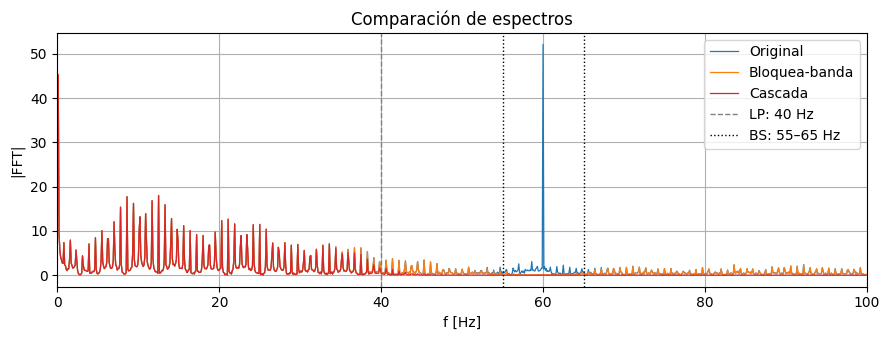

In [39]:
plt.figure(figsize=(9, 3.5))
plot_spectrum(ecg, fs, N, label="Original")
plot_spectrum(ecg_bs, fs, N, label="Bloquea-banda", color="tab:orange")
plot_spectrum(ecg_bs_lp, fs, N, label="Cascada", color="tab:red")
plt.axvline(x=fc, color="gray", linestyle="--", linewidth=1, label=f"LP: {fc} Hz")
plt.axvline(x=fc1, color="black", linestyle=":", linewidth=1)
plt.axvline(x=fc2, color="black", linestyle=":", linewidth=1, label=f"BS: {fc1}–{fc2} Hz")
plt.title("Comparación de espectros")
plt.legend()
plt.tight_layout()

## Resumen

| Filtro | Tipo | $M$ | Ventana | Objetivo |
|--------|------|-----|---------|----------|
| Pasa-bajos | LP | 40 | Hamming | Eliminar ruido > 40 Hz |
| Bloquea-banda | BS | 80 | Hamming | Eliminar interferencia 55–65 Hz |

**Observaciones:**
- Los filtros FIR tienen **fase lineal**, lo que preserva la forma de onda del ECG.
- Los filtros FIR tienen **solo ceros** (no hay polos dentro del círculo unitario), por lo que son siempre estables.
- Al aumentar $M$, los ceros se acumulan sobre el círculo unitario en la banda de bloqueo, mejorando la selectividad.
- La ventana de Hamming reduce el rizado (Gibbs) a expensas de una zona de transición más ancha.